### Data Wrangling : Products

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from pathlib import Path

# Load dataset
data_path = Path("data/raw/products.csv")
if not data_path.exists():
    data_path = Path("../data/raw/products.csv")  

df = pd.read_csv(data_path)
df.head()
                               

,product_id,product_name,category,cost_price,selling_price,stock_available
0,P001,Cotton Kurta,Apparel,8.0,19.99,132
1,P002,Formal Shirt,Apparel,12.0,34.99,465
2,P003,Denim Jeans,Apparel,18.0,54.99,378
3,P004,Ethnic Saree,Apparel,22.0,79.99,300
4,P005,Winter Jacket,Apparel,35.0,99.99,136


In [3]:
# Shape of dataset
df.shape

(40, 6)

In [4]:
# Statistical summary 
df.describe()

,cost_price,selling_price,stock_available
count,40.000000,40.000000,40.000000
mean,21.925000,55.390250,268.650000
std,23.178944,48.717051,135.759506
min,2.000000,6.990000,50.000000
25%,8.000000,24.490000,147.250000
50%,15.000000,39.990000,273.500000
75%,22.000000,61.240000,375.000000
max,95.000000,210.000000,496.000000


In [5]:
# Check data types
df.dtypes

product_id             str
product_name           str
category               str
cost_price         float64
selling_price      float64
stock_available      int64
dtype: object

In [6]:
# Null values
df.isnull().sum()

product_id         0
product_name       0
category           0
cost_price         0
selling_price      0
stock_available    0
dtype: int64

In [7]:
# Duplicated values
df.duplicated().sum()

np.int64(0)

In [8]:
# Data validation for cost_price and selling_price
errors = df[df['selling_price'] >= df['cost_price'] ]
print(len(errors))

40


In [9]:
# Validation for stock available
avail = df['stock_available']<0
print(len(avail))

40


In [10]:
# Profit column
df['profit'] = df['selling_price'] - df['cost_price']
df['profit'].head()

0    11.99
1    22.99
2    36.99
3    57.99
4    64.99
Name: profit, dtype: float64

In [11]:
# Profit margin column 
df['margin'] = df['profit']/df['selling_price']
df['margin'].head()

0    0.599800
1    0.657045
2    0.672668
3    0.724966
4    0.649965
Name: margin, dtype: float64

In [12]:
# Stock value at cost
df['inventory_cost'] = df['cost_price']*df['stock_available']
df['inventory_cost'].head()

0    1056.0
1    5580.0
2    6804.0
3    6600.0
4    4760.0
Name: inventory_cost, dtype: float64

In [13]:
# Potential revenue 
df['inventory_revenue'] = df['selling_price']*df['stock_available']
df['inventory_revenue'].head()

0     2638.68
1    16270.35
2    20786.22
3    23997.00
4    13598.64
Name: inventory_revenue, dtype: float64

In [14]:
# Inventory Risk
# Thresholds (top 25% stock, bottom 25% margin)
stock_threshold = df['stock_available'].quantile(0.75)
margin_threshold = df['margin'].quantile(0.25)

df['inventory_risk'] = (
    (df['stock_available'] > stock_threshold) &
    (df['margin'] < margin_threshold)
)
df['inventory_risk'].head()

0    False
1    False
2    False
3    False
4    False
Name: inventory_risk, dtype: bool

In [15]:
# Add labels
df['inventory_risk_label'] = df['inventory_risk'].map({
    True: 'High Risk',
    False: 'Normal'
})
df['inventory_risk_label'].head()

0    Normal
1    Normal
2    Normal
3    Normal
4    Normal
Name: inventory_risk_label, dtype: str

In [16]:
# Price bucket
df['price_bucket'] = pd.qcut(
    df['selling_price'],
    q=3,
    labels=['Low Price', 'Mid Price', 'High Price']
)
df['price_bucket'].head()

0     Low Price
1     Mid Price
2     Mid Price
3    High Price
4    High Price
Name: price_bucket, dtype: category
Categories (3, str): ['Low Price' < 'Mid Price' < 'High Price']

### Insights

In [17]:
# Q1. How many risky products?
df['inventory_risk_label'].value_counts()

inventory_risk_label
Normal       37
High Risk     3
Name: count, dtype: int64

In [18]:
# Q2. Money stuck in risky inventory
df[df['inventory_risk']]['inventory_cost'].sum()

np.float64(101770.0)

In [19]:
# Q3. Avg margin by price bucket
df.groupby('price_bucket')['margin'].mean()

price_bucket
Low Price     0.674881
Mid Price     0.636866
High Price    0.594643
Name: margin, dtype: float64

C:\Users\kaurs\AppData\Local\Temp\ipykernel_29260\3933330473.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_profit.index, y=category_profit.values, palette='Blues_r')


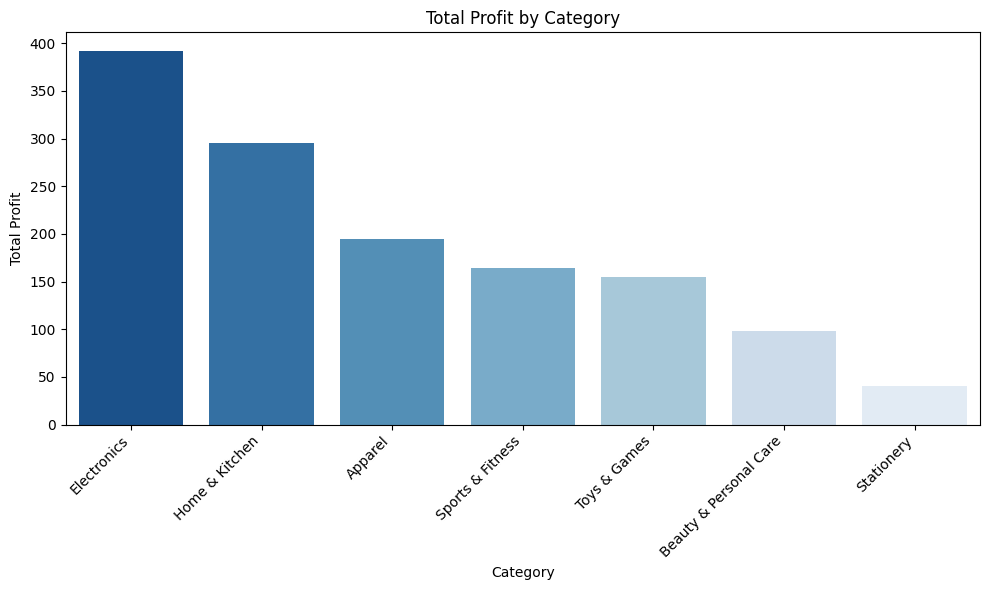

Total profit across all categories: 1,338.61
Top category by total profit: Electronics (391.94), which is 29.28% of total profit
Gap between 1st and 2nd category profit: 97.00


In [20]:
# Q4. Which category contributes most to overall profit?
category_profit = df.groupby('category')['profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=category_profit.index, y=category_profit.values, palette='Blues_r')
plt.title('Total Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Mathematical insights
total_profit = category_profit.sum()
top_profit_cat = category_profit.index[0]
top_profit_val = category_profit.iloc[0]
second_profit_val = category_profit.iloc[1] if len(category_profit) > 1 else 0
top_profit_share = (top_profit_val / total_profit) * 100 if total_profit != 0 else 0
profit_gap = top_profit_val - second_profit_val

print(f"Total profit across all categories: {total_profit:,.2f}")
print(
    f"Top category by total profit: {top_profit_cat} ({top_profit_val:,.2f}), "
    f"which is {top_profit_share:.2f}% of total profit"
 )
print(f"Gap between 1st and 2nd category profit: {profit_gap:,.2f}")

C:\Users\kaurs\AppData\Local\Temp\ipykernel_29260\3025902770.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_profit.index, y=avg_profit.values, palette='Greens_r')


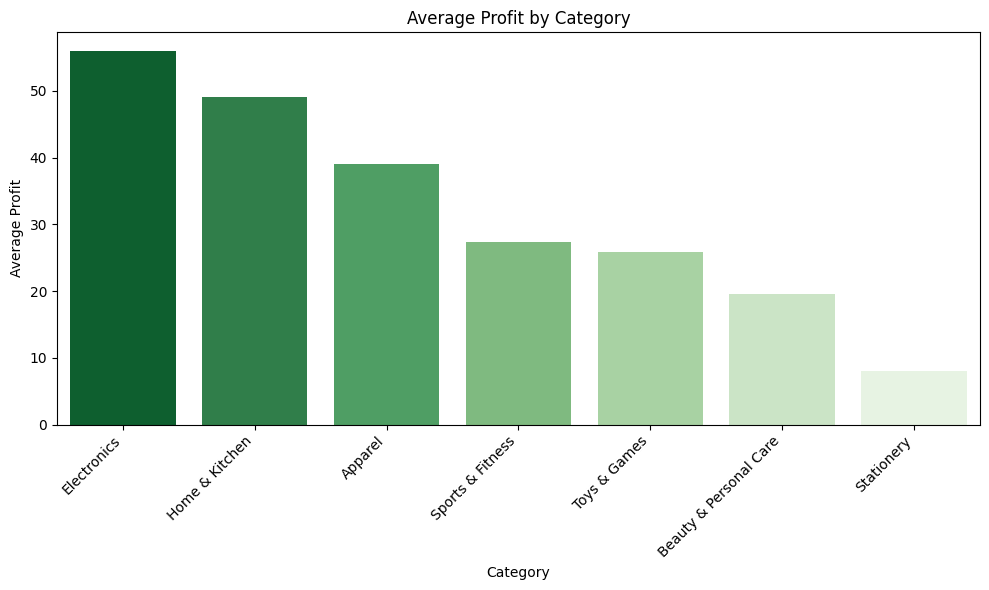

Highest average-profit category: Electronics (55.99)
Top category lift vs median category avg profit: 104.92%
Top-to-bottom average profit ratio: 7.01x


In [21]:
# Q5. Which category has more profitable products on average?
avg_profit = df.groupby('category')['profit'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_profit.index, y=avg_profit.values, palette='Greens_r')
plt.title('Average Profit by Category')
plt.xlabel('Category')
plt.ylabel('Average Profit')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Mathematical insights
top_avg_profit_cat = avg_profit.index[0]
top_avg_profit = avg_profit.iloc[0]
median_avg_profit = avg_profit.median()
bottom_avg_profit = avg_profit.iloc[-1]
lift_vs_median = ((top_avg_profit - median_avg_profit) / median_avg_profit) * 100 if median_avg_profit != 0 else 0
top_vs_bottom_ratio = top_avg_profit / bottom_avg_profit if bottom_avg_profit != 0 else np.nan

print(f"Highest average-profit category: {top_avg_profit_cat} ({top_avg_profit:,.2f})")
print(f"Top category lift vs median category avg profit: {lift_vs_median:.2f}%")
print(f"Top-to-bottom average profit ratio: {top_vs_bottom_ratio:.2f}x")

C:\Users\kaurs\AppData\Local\Temp\ipykernel_29260\3649915265.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_margin.index, y=avg_margin.values, palette='Oranges_r')


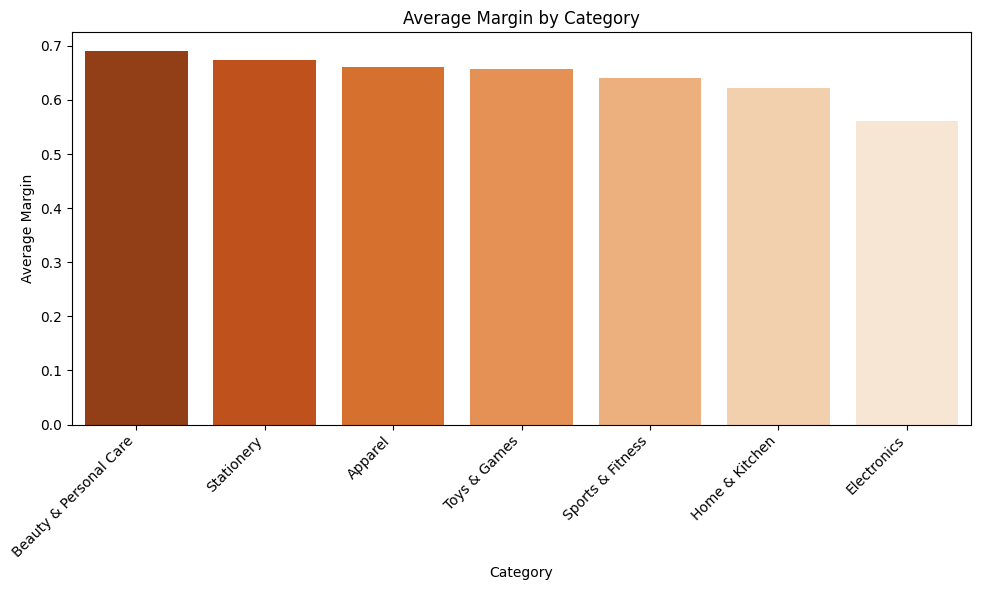

Best pricing-power category: Beauty & Personal Care (69.05% average margin)
Margin spread between best and worst category: 12.94 percentage points
Top category margin premium vs overall weighted margin: 8.63 percentage points


In [22]:
# Q6. Which category has better pricing power?
avg_margin = df.groupby('category')['margin'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_margin.index, y=avg_margin.values, palette='Oranges_r')
plt.title('Average Margin by Category')
plt.xlabel('Category')
plt.ylabel('Average Margin')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Mathematical insights
top_margin_cat = avg_margin.index[0]
top_margin = avg_margin.iloc[0]
weighted_margin = (df['profit'].sum() / df['selling_price'].sum()) if df['selling_price'].sum() != 0 else 0
bottom_margin = avg_margin.iloc[-1]
margin_spread_pct_points = (top_margin - bottom_margin) * 100
premium_vs_weighted = (top_margin - weighted_margin) * 100

print(f"Best pricing-power category: {top_margin_cat} ({top_margin:.2%} average margin)")
print(f"Margin spread between best and worst category: {margin_spread_pct_points:.2f} percentage points")
print(f"Top category margin premium vs overall weighted margin: {premium_vs_weighted:.2f} percentage points")

C:\Users\kaurs\AppData\Local\Temp\ipykernel_29260\1177960458.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=inventory_value.index, y=inventory_value.values, palette='Purples_r')


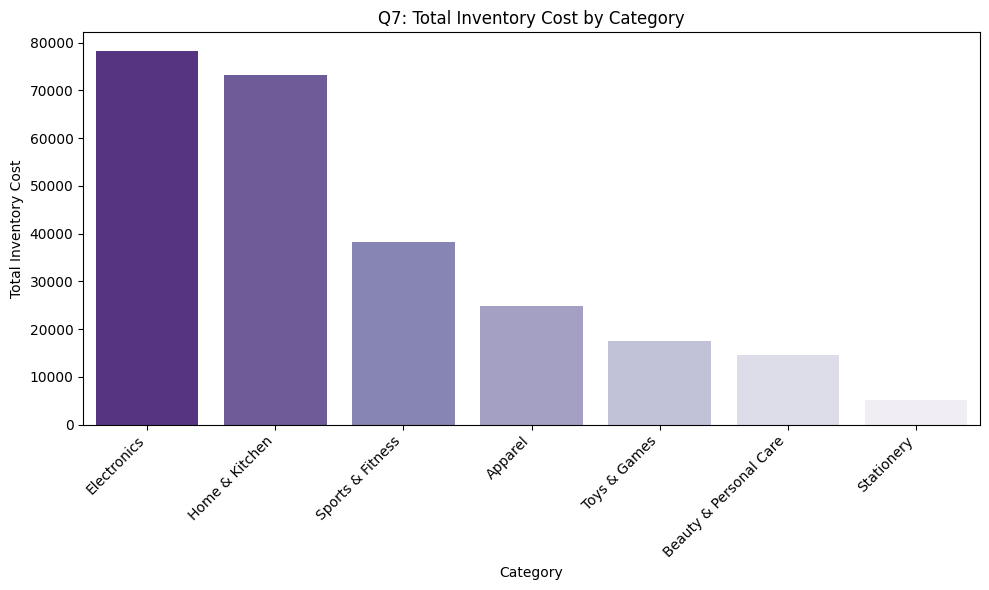

Total inventory cost across all categories: 251,541.00
Most capital-invested category: Electronics (78,252.00), holding 31.11% of total inventory capital
Capital gap between 1st and 2nd category: 4,999.00


In [23]:
# Q7. Where is most capital invested?
inventory_value = df.groupby('category')['inventory_cost'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=inventory_value.index, y=inventory_value.values, palette='Purples_r')
plt.title('Q7: Total Inventory Cost by Category')
plt.xlabel('Category')
plt.ylabel('Total Inventory Cost')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Mathematical insights
total_inventory_cost = inventory_value.sum()
top_inventory_cat = inventory_value.index[0]
top_inventory_cost = inventory_value.iloc[0]
second_inventory_cost = inventory_value.iloc[1] if len(inventory_value) > 1 else 0
capital_concentration = (top_inventory_cost / total_inventory_cost) * 100 if total_inventory_cost != 0 else 0
capital_gap = top_inventory_cost - second_inventory_cost

print(f"Total inventory cost across all categories: {total_inventory_cost:,.2f}")
print(
    f"Most capital-invested category: {top_inventory_cat} ({top_inventory_cost:,.2f}), "
    f"holding {capital_concentration:.2f}% of total inventory capital"
 )
print(f"Capital gap between 1st and 2nd category: {capital_gap:,.2f}")

In [24]:
# Save dataset
output_path = Path("data/processed/products_enriched.csv")
if not output_path.parent.exists():
    output_path = Path("../data/processed/products_enriched.csv")

output_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_path, index=False)